In [1]:
import os
import cv2
import numpy as np
import pickle #Save objects (like models, data) into a file , Load them back later
!pip install mtcnn
!pip install keras-facenet
from mtcnn import MTCNN
from keras_facenet import FaceNet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for keras-facenet: filename=keras_facenet-0.3.2-py3-none-any.whl size=10367 sha256=f5b97f638d96a6c36c40d053b51822ead6ec2cf47efd995dc4564774335333d5
  Stored in directory: /root/.cache/pip/wheels/05/b0/f5/19ac49fedc10b1df3ee56b096edbcfa39d45794fccc6bcdbbf
Successfully built keras-facenet


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dataset_path = "/content/drive/MyDrive/SAS_CV_2026/Dataset/Dataset_MLC"

import os
print(os.listdir(dataset_path))

['Arish', 'Anna', 'Divya', 'Ravi', 'Manish', 'Gayathri', 'Jintu', 'Shreya', 'Srinithi', 'Ujjal', 'Veenus']


In [ ]:
print("Script started...")

# Initialize
detector = MTCNN()
embedder = FaceNet()

DATASET_PATH = "/content/drive/MyDrive/SAS_CV_2026/Dataset/Dataset_MLC"
EMBEDDINGS_PATH = "embeddings.pkl"

known_embeddings = []
known_labels = []

In [5]:
import os
import cv2
import numpy as np
import pickle
from keras_facenet import FaceNet
from tqdm import tqdm   # progress bar

print("Embedding script started...")

# Initialize FaceNet
embedder = FaceNet()
print("FaceNet loaded")

# Paths
DATASET_PATH = "/content/drive/MyDrive/SAS_CV_2026/Dataset/Dataset_MLC"   # change if needed
EMBEDDINGS_DIR = "Embeddings"
EMBEDDINGS_PATH = os.path.join(EMBEDDINGS_DIR, "embeddings_mlc.pkl")

os.makedirs(EMBEDDINGS_DIR, exist_ok=True)

# Storage
known_embeddings = []
known_labels = []

# Batch settings
BATCH_SIZE = 32
faces_batch = []
labels_batch = []

# Count total images
total_images = sum([len(files) for _, _, files in os.walk(DATASET_PATH)])
print(f"Total images: {total_images}")

# Loop through dataset
for person_name in os.listdir(DATASET_PATH):
    person_folder = os.path.join(DATASET_PATH, person_name)

    if not os.path.isdir(person_folder):
        continue

    print(f"\nProcessing: {person_name}")

    for image_name in tqdm(os.listdir(person_folder)):
        image_path = os.path.join(person_folder, image_name)

        img = cv2.imread(image_path)
        if img is None:
            continue

        # FAST: skip detection, resize directly
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        face = cv2.resize(img_rgb, (160, 160))

        faces_batch.append(face)
        labels_batch.append(person_name)

        # Batch processing
        if len(faces_batch) == BATCH_SIZE:
            embeddings = embedder.embeddings(faces_batch)

            known_embeddings.extend(embeddings)
            known_labels.extend(labels_batch)

            faces_batch = []
            labels_batch = []

# Process remaining batch
if faces_batch:
    embeddings = embedder.embeddings(faces_batch)
    known_embeddings.extend(embeddings)
    known_labels.extend(labels_batch)

print("\n Total embeddings:", len(known_embeddings))

# Save
data = {
    "embeddings": known_embeddings,
    "labels": known_labels
}

with open(EMBEDDINGS_PATH, "wb") as f:
    pickle.dump(data, f)

print(" Embeddings saved successfully!")
print(" Location:", EMBEDDINGS_PATH)

🚀 Ultra-fast embedding script started...
✅ FaceNet loaded
Total images: 4938

Processing: Arish


  6%|▋         | 29/449 [00:07<00:58,  7.23it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


 13%|█▎        | 60/449 [00:16<00:59,  6.49it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


 96%|█████████▌| 432/449 [00:47<00:01, 16.62it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


100%|██████████| 449/449 [00:49<00:00,  9.01it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

 Total embeddings: 4938
 Embeddings saved successfully!
 Location: Embeddings/embeddings_mlc.pkl


In [6]:
# Embedding Information
with open("Embeddings/embeddings_mlc.pkl", "rb") as f:
    data = pickle.load(f)

print("Embedding shape:", np.array(data["embeddings"]).shape) # sample
print("Single embedding length:", len(data["embeddings"][0])) # dimensional vector
print("Persons:", set(data["labels"]))

Embedding shape: (4938, 512)
Single embedding length: 512
Persons: {'Manish', 'Ujjal', 'Divya', 'Gayathri', 'Anna', 'Srinithi', 'Ravi', 'Veenus', 'Arish', 'Shreya', 'Jintu'}


In [7]:
from collections import Counter

count = Counter(data["labels"])
print(count)

Counter({'Arish': 449, 'Anna': 449, 'Divya': 449, 'Ravi': 449, 'Manish': 449, 'Gayathri': 449, 'Jintu': 449, 'Shreya': 449, 'Ujjal': 449, 'Veenus': 449, 'Srinithi': 448})


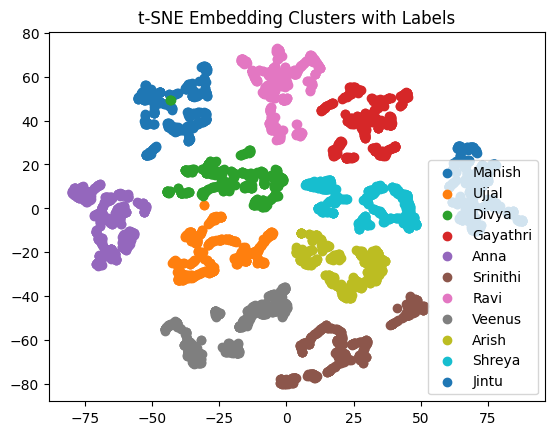

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

X = np.array(data["embeddings"])
labels = np.array(data["labels"])

# Reduce to 2D
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)

# Plot
plt.figure()

for label in set(labels):
    idx = labels == label
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], label=label)

plt.legend()
plt.title("t-SNE Embedding Clusters with Labels")
plt.show()

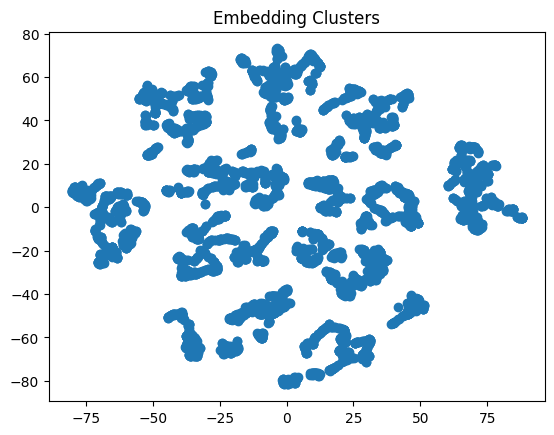

In [9]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

X = np.array(data["embeddings"])

X_2d = TSNE(n_components=2).fit_transform(X)

plt.scatter(X_2d[:,0], X_2d[:,1])
plt.title("Embedding Clusters")
plt.show()